# **Análisis Exploratorio de Datos**

### Integrantes

| Nombre | Matrícula |
|---|---|
| Montserrat Gaytán Morales | A01332220 |
| Alberto Eduardo De Zamacona Garza | A00590592 |
| Ernesto Ignacio Borbón Martínez | A01701515 |

---

## Librerias

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np    # importamos Numpy para el manejo de los arreglos.
import re             # importamos re para el manejo de las expresiones regulares.

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = "/content/drive/MyDrive/PI - Eq9/data.csv"

df = pd.read_csv(file_path)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1506 entries, 0 to 1505
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  1506 non-null   int64  
 1   perfil_cliente_contratante          1506 non-null   int64  
 2   perfil_cliente_final                1506 non-null   int64  
 3   relacion_contratante_cliente_final  1506 non-null   int64  
 4   calidad_solicitud                   1506 non-null   int64  
 5   presion_preventa                    1506 non-null   int64  
 6   complejidad_preproyecto             1506 non-null   int64  
 7   Material_Cost                       1506 non-null   object 
 8   Labor_Cost                          1506 non-null   object 
 9   costo_directo_estimado              1506 non-null   object 
 10  costo_administrativo_estimado       1506 non-null   int64  
 11  utilidad_objetivo_pct_Procentaje    1506 no

In [5]:
cols = [
    'Material_Cost',
    'Labor_Cost',
    'costo_directo_estimado',
    'factor_indirecto_comercial_pct',
    'estrategia_precio'
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1506 entries, 0 to 1505
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  1506 non-null   int64  
 1   perfil_cliente_contratante          1506 non-null   int64  
 2   perfil_cliente_final                1506 non-null   int64  
 3   relacion_contratante_cliente_final  1506 non-null   int64  
 4   calidad_solicitud                   1506 non-null   int64  
 5   presion_preventa                    1506 non-null   int64  
 6   complejidad_preproyecto             1506 non-null   int64  
 7   Material_Cost                       1000 non-null   float64
 8   Labor_Cost                          1000 non-null   float64
 9   costo_directo_estimado              1000 non-null   float64
 10  costo_administrativo_estimado       1506 non-null   int64  
 11  utilidad_objetivo_pct_Procentaje    1506 no

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

from scipy.stats import skew

# **Vista general del dataset**

Se realiza una revisión inicial con el fin de conocer la estructura del conjunto de datos, los tipos de variables y el tamaño de la muestra.
Anteriormente se realizó el cambio de *type* para algunas variables.

In [8]:
df.head() # Primeras filas

,id,perfil_cliente_contratante,perfil_cliente_final,relacion_contratante_cliente_final,calidad_solicitud,presion_preventa,complejidad_preproyecto,Material_Cost,Labor_Cost,costo_directo_estimado,...,utilidad_objetivo_pct_Procentaje,utilidad_objetivo_pct_monto,prima_cliente_pct_porcentje,prima_cliente_pct_monto,factor_indirecto_comercial_pct,Policy_Reason,estrategia_precio,resultado_comercial,desviacion_ajustada,proyecto_redituable
0,1,3,2,2,3,7,3,43985.0,12836.0,56821.0,...,10,5682.10,1.93,1095.0,6777.10,Market conditions require competitive pricing ...,63598.10,1,0,1
1,2,3,2,2,3,7,4,45504.0,17873.0,63377.0,...,15,9506.55,-10.14,-6426.0,3080.55,Market conditions require competitive pricing ...,66457.55,1,0,1
2,3,3,3,3,4,21,1,33656.0,8401.0,42057.0,...,25,10514.25,23.45,9862.0,20376.25,"The client is a repeat customer, deserving a l...",62433.25,1,0,1
3,4,3,3,3,4,21,1,36509.0,8523.0,45032.0,...,20,9006.40,17.98,8096.0,17102.40,"The client is a repeat customer, deserving a l...",62134.40,1,0,1
4,5,3,4,4,3,7,4,37372.0,14123.0,51495.0,...,30,15448.50,-18.64,-9598.0,5850.50,Strategic importance of this client justifies ...,57345.50,1,0,1


In [9]:
df.info() # Información general

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1506 entries, 0 to 1505
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  1506 non-null   int64  
 1   perfil_cliente_contratante          1506 non-null   int64  
 2   perfil_cliente_final                1506 non-null   int64  
 3   relacion_contratante_cliente_final  1506 non-null   int64  
 4   calidad_solicitud                   1506 non-null   int64  
 5   presion_preventa                    1506 non-null   int64  
 6   complejidad_preproyecto             1506 non-null   int64  
 7   Material_Cost                       1000 non-null   float64
 8   Labor_Cost                          1000 non-null   float64
 9   costo_directo_estimado              1000 non-null   float64
 10  costo_administrativo_estimado       1506 non-null   int64  
 11  utilidad_objetivo_pct_Procentaje    1506 no

In [10]:
print(df.shape) # Dimensiones

(1506, 21)


# **Valores faltantes**
¿Hay valores faltantes en el conjunto de datos? ¿Se pueden identificar patrones de ausencia?

In [11]:
df.isnull().sum() # Conteo

,0
id,0
perfil_cliente_contratante,0
perfil_cliente_final,0
relacion_contratante_cliente_final,0
calidad_solicitud,0
presion_preventa,0
complejidad_preproyecto,0
Material_Cost,506
Labor_Cost,506
costo_directo_estimado,506


In [12]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct.sort_values(ascending=False) # Porcentaje

,0
estrategia_precio,33.598938
factor_indirecto_comercial_pct,33.598938
costo_directo_estimado,33.598938
Material_Cost,33.598938
Labor_Cost,33.598938
calidad_solicitud,0.000000
relacion_contratante_cliente_final,0.000000
perfil_cliente_final,0.000000
perfil_cliente_contratante,0.000000
id,0.000000


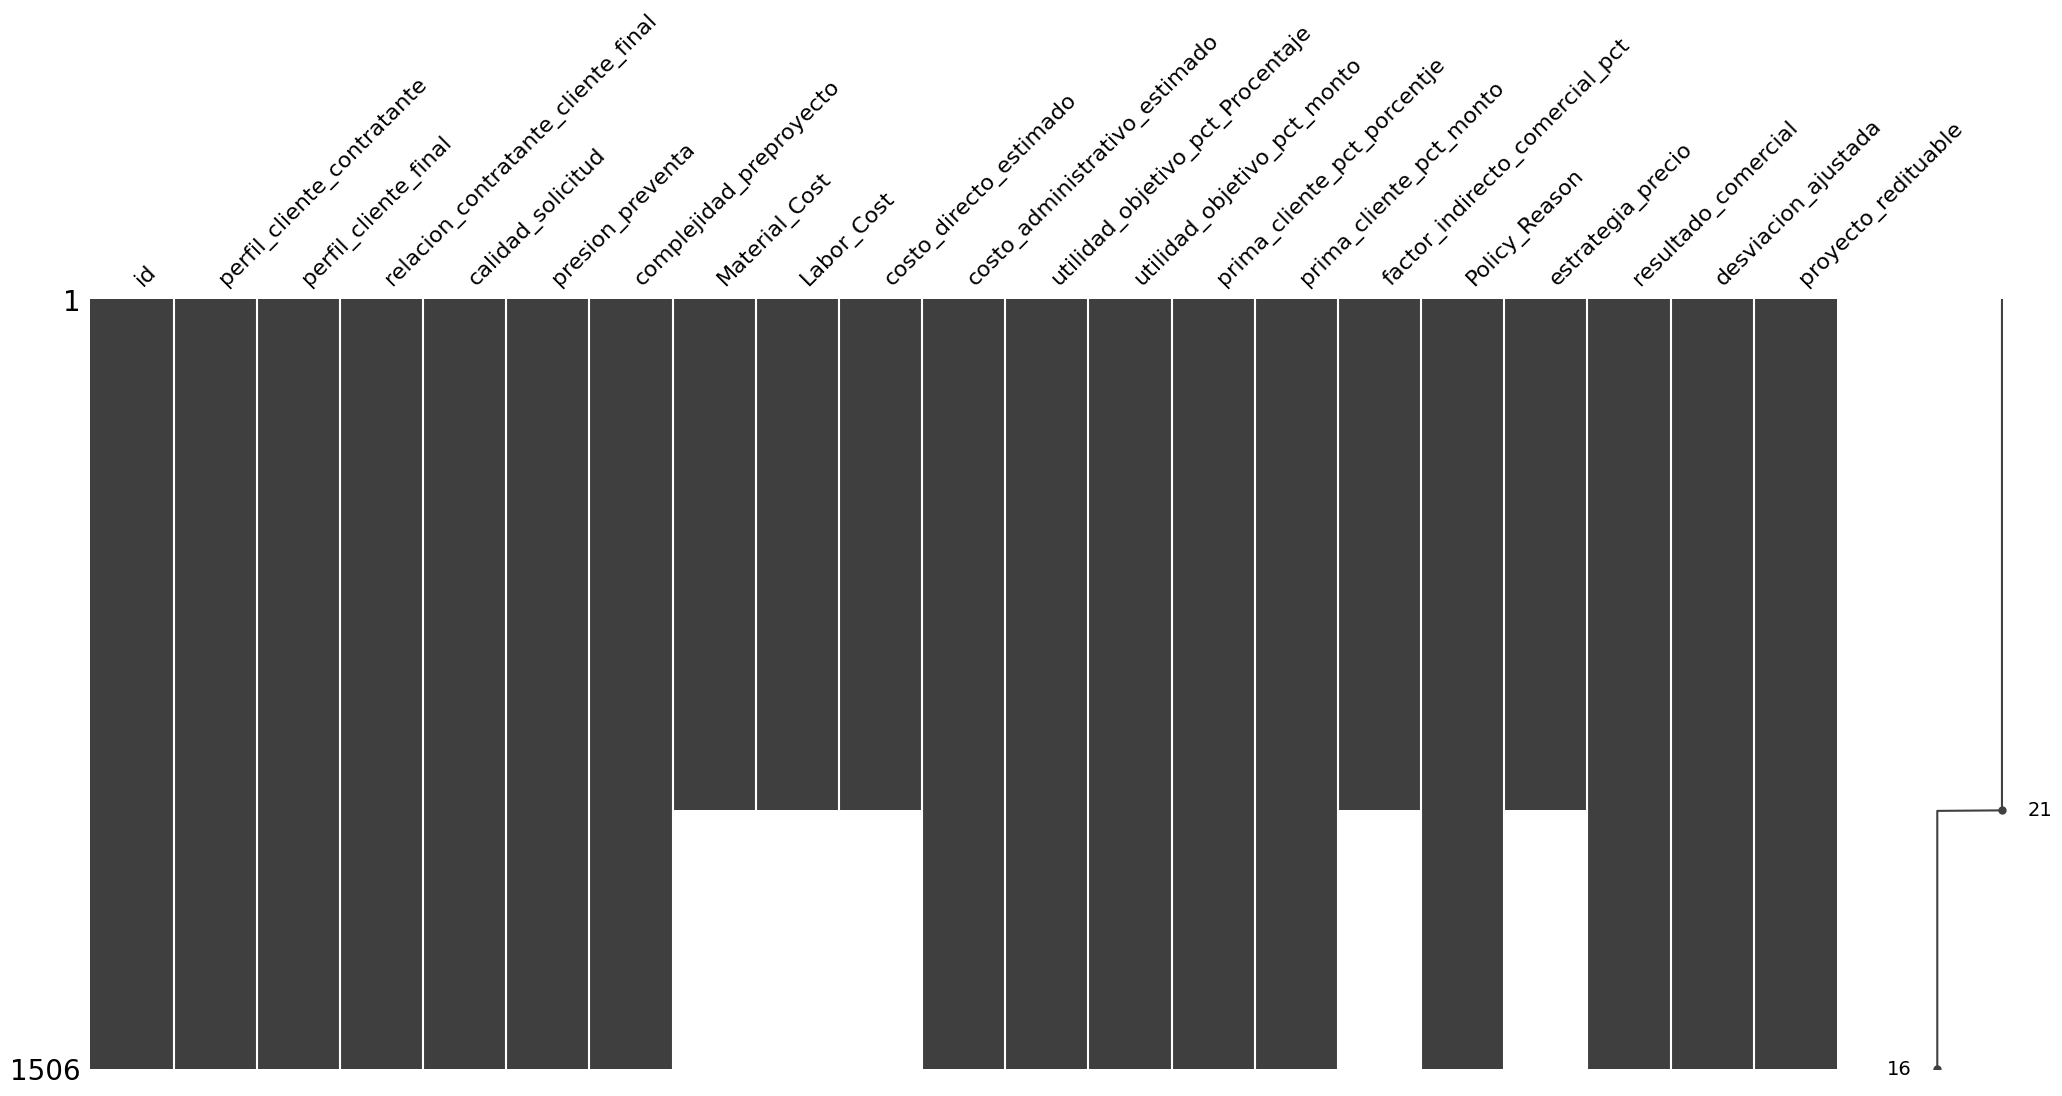

In [13]:
msno.matrix(df)
plt.show()

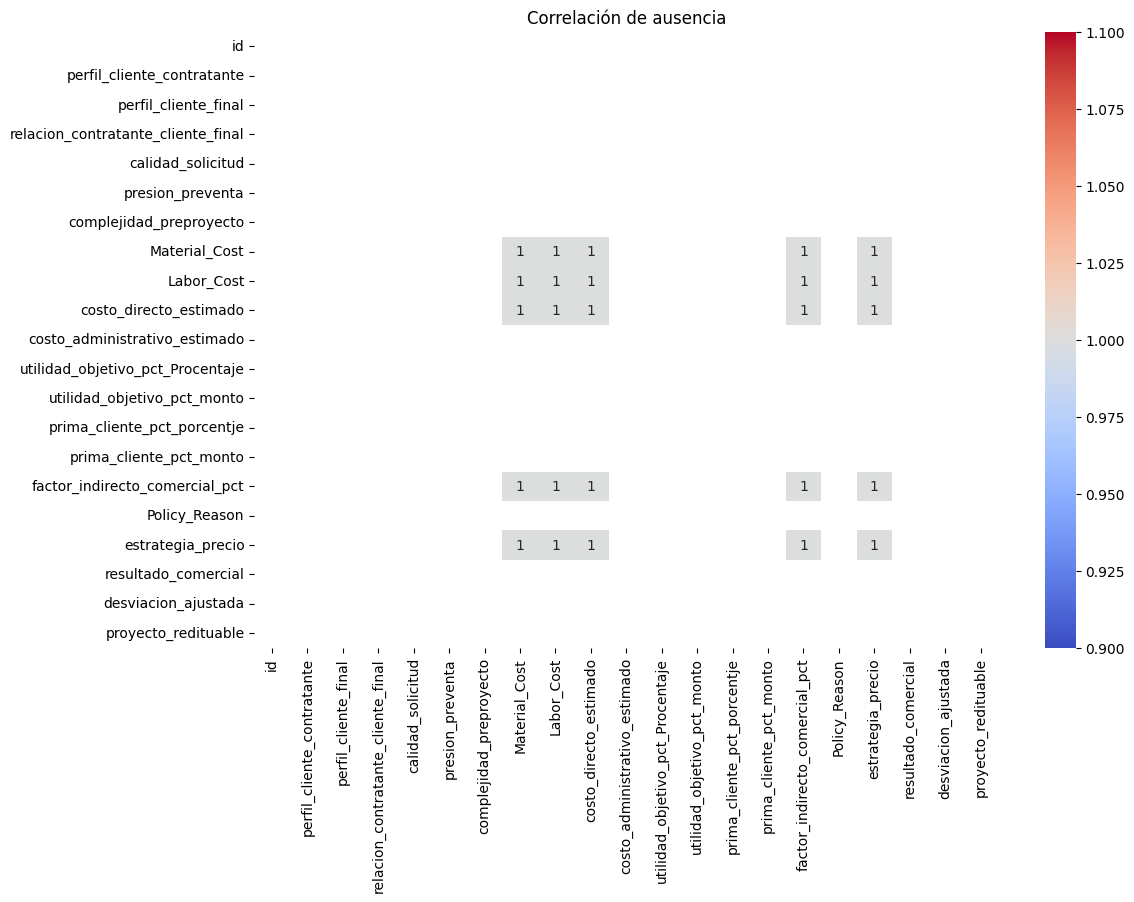

In [14]:
missing_corr = df.isnull().corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    missing_corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlación de ausencia')

plt.show()

El análisis de correlación de ausencia mostró patrones consistentes de valores faltantes entre variables relacionadas con costos y estrategia comercial. La ausencia conjunta sugiere que ciertos registros presentan captura parcial de información asociada a etapas específicas del proceso comercial o administrativo, en lugar de faltantes aleatorios.

# **Estadísticas resumidas**
¿Cuáles son las estadísticas resumidas del conjunto de datos?

In [15]:
# Estadísticas numéricas
df.describe()

,id,perfil_cliente_contratante,perfil_cliente_final,relacion_contratante_cliente_final,calidad_solicitud,presion_preventa,complejidad_preproyecto,Material_Cost,Labor_Cost,costo_directo_estimado,costo_administrativo_estimado,utilidad_objetivo_pct_Procentaje,utilidad_objetivo_pct_monto,prima_cliente_pct_porcentje,prima_cliente_pct_monto,factor_indirecto_comercial_pct,estrategia_precio,resultado_comercial,desviacion_ajustada,proyecto_redituable
count,1506.000000,1506.000000,1506.000000,1506.000000,1506.000000,1506.000000,1506.000000,1000.00000,1000.000000,1000.000000,1506.0,1506.000000,1506.000000,1506.000000,1506.000000,1000.000000,1000.000000,1506.000000,1506.0,1506.000000
mean,753.500000,2.500000,2.821381,2.470784,2.577025,10.895086,3.549801,29908.74700,17566.307000,47475.054000,0.0,19.843958,9395.950432,-0.119230,-48.788181,9294.638700,56769.692700,1.335989,0.0,1.070385
std,434.889066,1.118999,0.776290,1.027597,1.031583,5.548902,0.686251,11200.10159,7225.096808,13536.679814,0.0,6.985430,4306.030951,11.506332,4684.932898,7089.430399,17465.481663,0.472492,0.0,0.255880
min,1.000000,1.000000,2.000000,1.000000,1.000000,7.000000,1.000000,10038.00000,5067.000000,15965.000000,0.0,10.000000,1596.500000,-44.470000,-9987.000000,-7313.300000,13319.150000,1.000000,0.0,1.000000
25%,377.250000,1.250000,2.000000,2.000000,2.000000,7.000000,3.000000,20528.00000,11462.500000,37486.000000,0.0,15.000000,5984.487500,-5.217500,-2469.500000,3725.950000,44069.300000,1.000000,0.0,1.000000
50%,753.500000,2.500000,3.000000,2.000000,3.000000,7.000000,4.000000,30023.50000,17591.500000,47482.000000,0.0,20.000000,8698.800000,0.000000,0.000000,9436.600000,57121.350000,1.000000,0.0,1.000000
75%,1129.750000,3.750000,3.000000,3.000000,3.000000,14.000000,4.000000,39438.75000,23738.750000,57408.750000,0.0,25.000000,12301.200000,5.035000,2449.500000,14404.212500,69295.100000,2.000000,0.0,1.000000
max,1506.000000,4.000000,4.000000,4.000000,4.000000,21.000000,4.000000,49947.00000,29923.000000,79588.000000,0.0,30.000000,23876.400000,56.080000,9979.000000,30241.800000,109165.400000,2.000000,0.0,2.000000


In [16]:
# Estadísticas categóricas
df.describe(include='object')

,Policy_Reason
count,1506
unique,6
top,Non-winning proposal
freq,506


La diferencia entre medias, medianas y valores máximos sugiere la presencia de proyectos con montos considerablemente mayores al promedio, común en entornos de construcción al existir proyectos de distinta escala.

Existen 1,506 registros distribuidos en 6 categorías distintas. La categoría más frecuente es "Non-winning proposal", con 506 observaciones (33%) dato relevante para analizar posibles desbalances entre categorías.

# **Valores atípicos**
¿Hay valores atípicos en el conjunto de datos?

In [17]:
numeric_cols = df.select_dtypes(include=np.number).columns

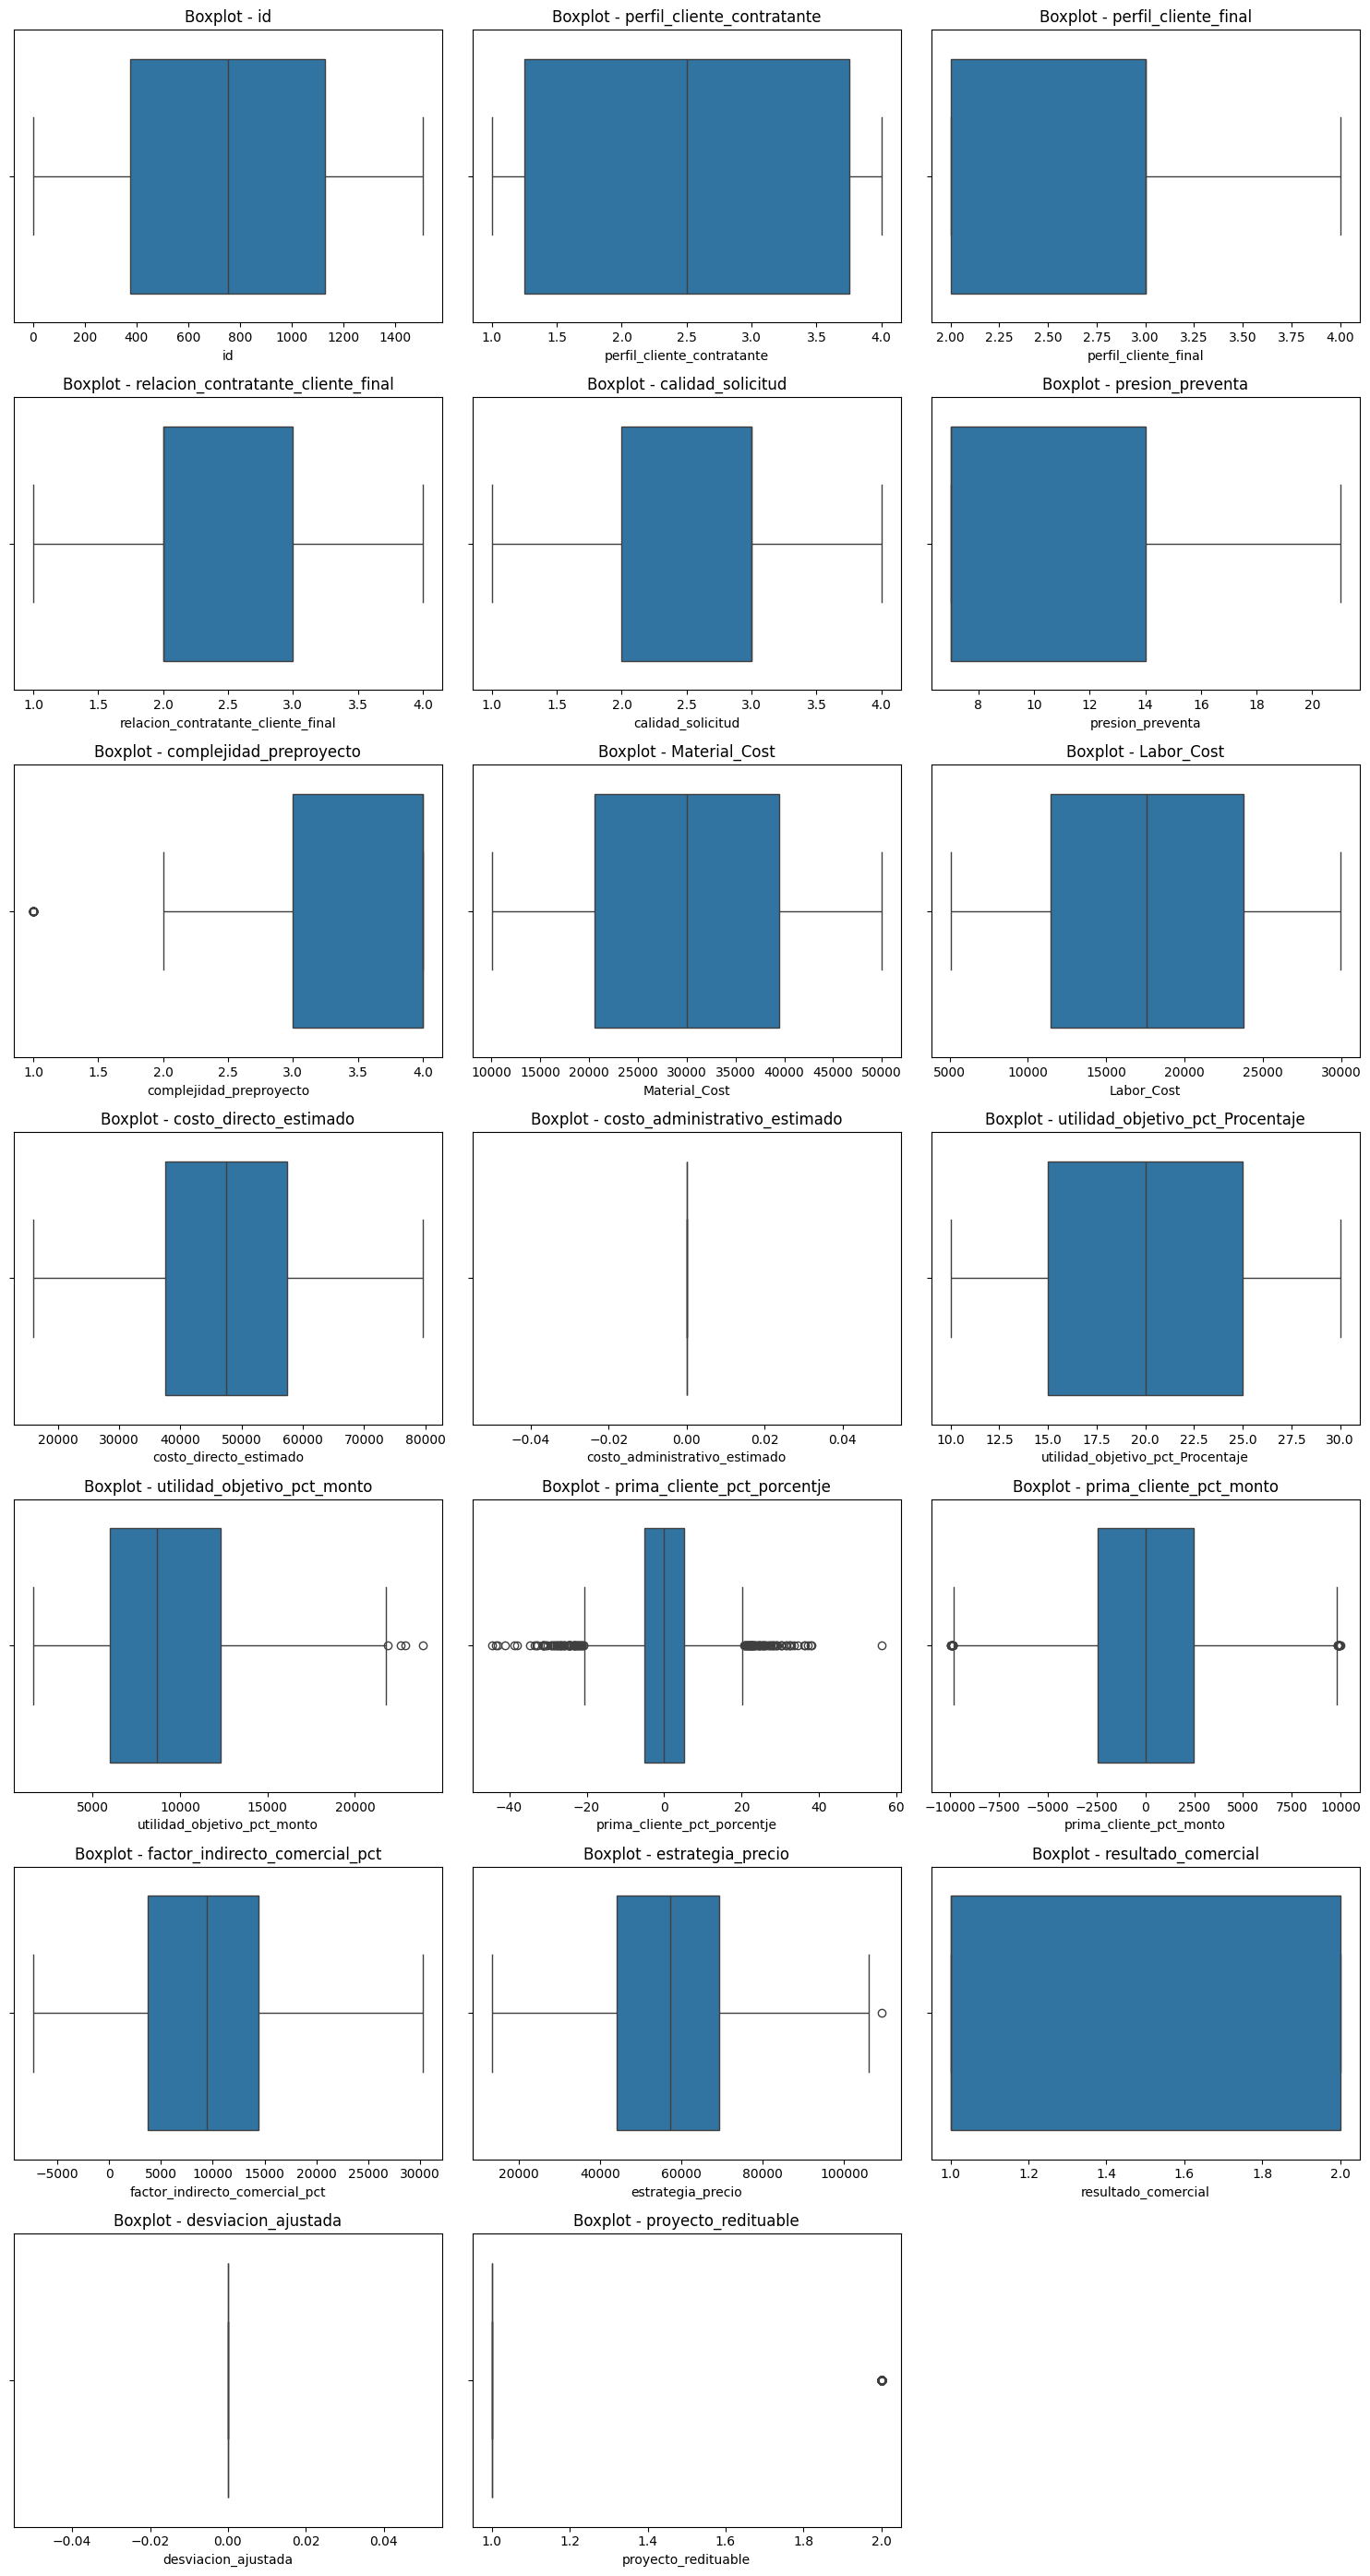

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

cols_per_row = 3
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / cols_per_row)

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(15, 4*n_rows))

# Convertir axes a arreglo plano para iterar fácil
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot - {col}')

# Eliminar ejes vacíos si sobran espacios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Los boxplots muestran la existencia de valores atípicos, principalmente en variables relacionadas a costos. Estos valores podrían corresponder a proyectos de gran magnitud por lo que no son eliminados en primera instancia, se evaluará su relevancia dentro del contexto del negocio.

# **Cardinalidad de variables categóricas**
¿Cuál es la cardinalidad de las variables categóricas?

In [19]:
categorical_cols = df.select_dtypes(include='object').columns

In [20]:
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} valores únicos")

Policy_Reason: 6 valores únicos


In [21]:
for col in categorical_cols:
    print(df[col].value_counts())
    print("\n")

Policy_Reason
Non-winning proposal                                                    506
Strategic importance of this client justifies special pricing.          224
This project includes additional risks, necessitating higher markup.    212
Market conditions require competitive pricing for this project.         199
The client is a repeat customer, deserving a loyalty discount.          190
This client is new but has potential for growth.                        175
Name: count, dtype: int64




Las frecuencias observadas indican que algunas categorías concentran gran parte de los registros, esto podría generar un desbalance en ciertas variables categóricas y afectar la capacidad del modelo para aprender patrones asociados a categorías poco frecuentes.

# **Distribuciones sesgadas**
¿Existen distribuciones sesgadas en el conjunto de datos? ¿Necesitamos aplicar alguna transformación no lineal?

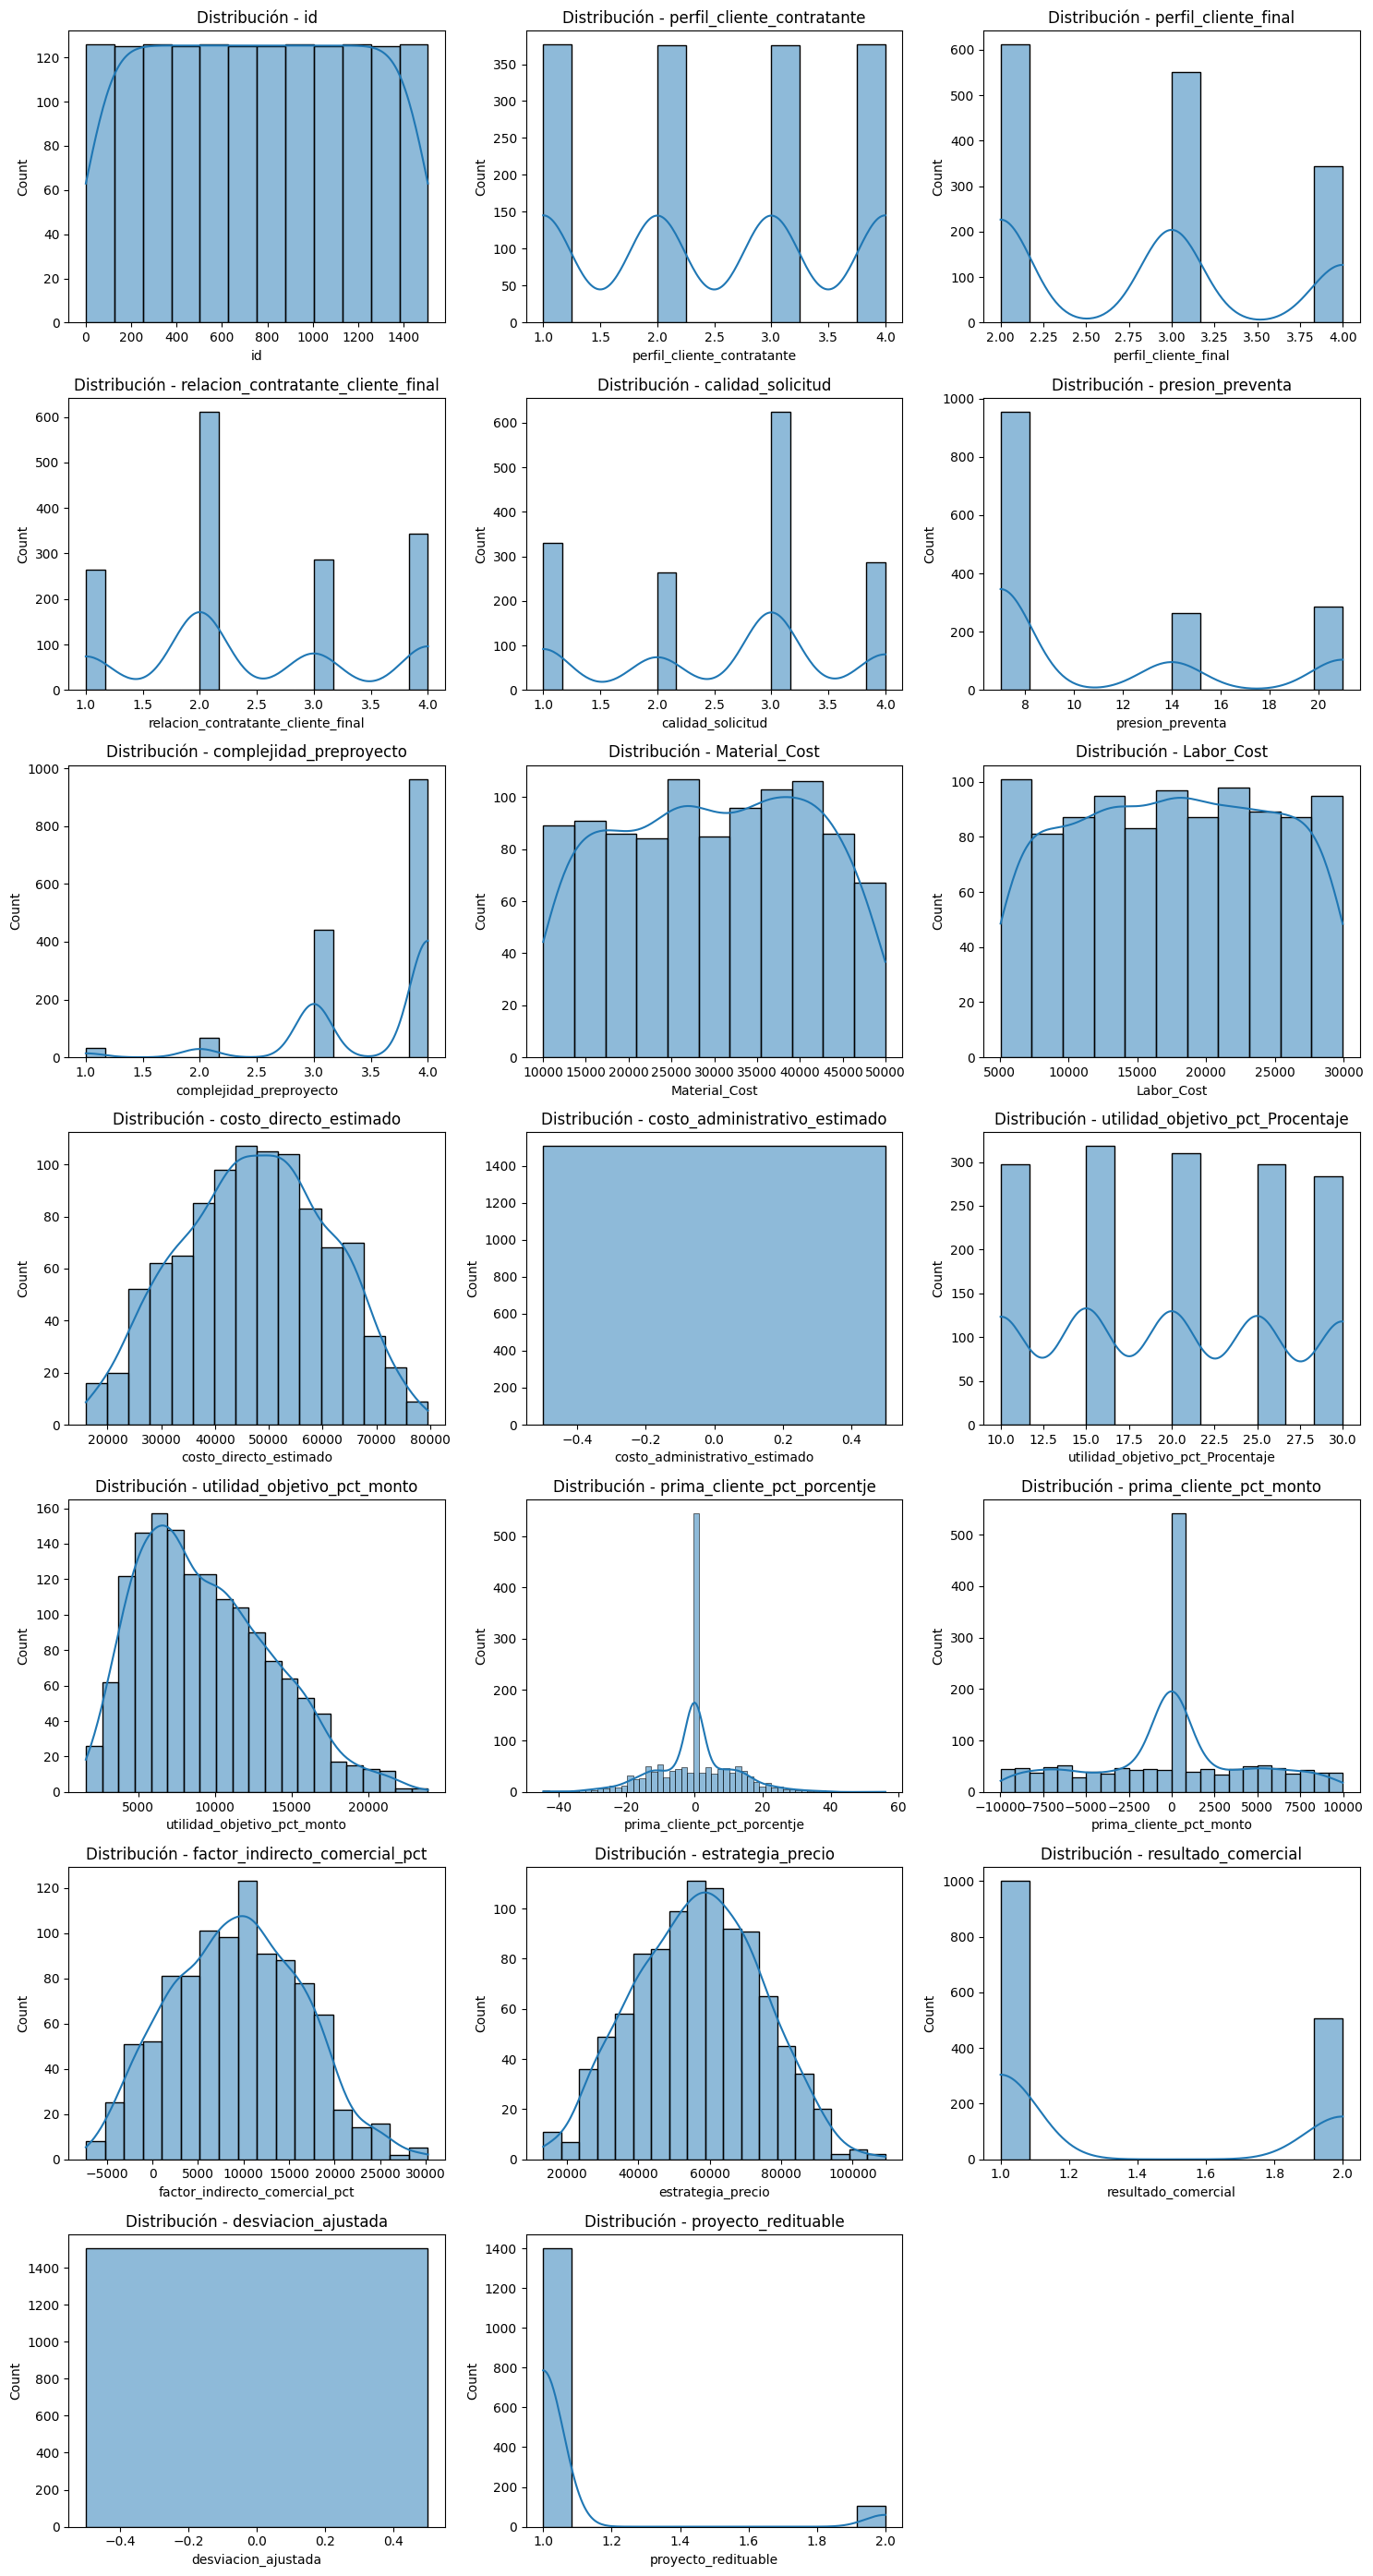

In [22]:
# Histogramas
cols_per_row = 3
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / cols_per_row)

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(15, 4*n_rows))

# Aplanar ejes
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución - {col}')

# Eliminar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [23]:
# Skewness
for col in numeric_cols:
    print(col, skew(df[col].dropna()))

id 0.0
perfil_cliente_contratante 0.0
perfil_cliente_final 0.32050417637268297
relacion_contratante_cliente_final 0.22378220533330212
calidad_solicitud -0.285039656789088
presion_preventa 0.9632251492713795
complejidad_preproyecto -1.6233651061092567
Material_Cost -0.04062684594930324
Labor_Cost -0.02079046455616935
costo_directo_estimado -0.05644946539922042
costo_administrativo_estimado nan
utilidad_objetivo_pct_Procentaje 0.03657995336558967
utilidad_objetivo_pct_monto 0.5722404086266664
prima_cliente_pct_porcentje -0.023321905949549693
prima_cliente_pct_monto -0.037440255184121404
factor_indirecto_comercial_pct 0.1124399789411859
estrategia_precio -0.0017584190632181887
resultado_comercial 0.6944671230376843
desviacion_ajustada nan
proyecto_redituable 3.3590566317830386


In [24]:
from scipy.stats import skew

for col in numeric_cols:

    skew_value = skew(df[col].dropna())

    if abs(skew_value) < 0.5:
        interpretation = "Distribución aproximadamente simétrica"
        recommendation = "No requiere transformación"

    elif abs(skew_value) < 1:
        interpretation = "Distribución moderadamente sesgada"
        recommendation = "Podría evaluarse transformación"

    elif np.isnan(skew_value):
        interpretation = "No se pudo calcular skewness"
        recommendation = "Revisar valores constantes o faltantes"

    else:
        interpretation = "Distribución altamente sesgada"
        recommendation = "Se recomienda transformación logarítmica o Box-Cox"

    print(f"\nVariable: {col}")
    print(f"Skewness: {skew_value:.2f}")
    print(f"Interpretación: {interpretation}")
    print(f"Recomendación: {recommendation}")


Variable: id
Skewness: 0.00
Interpretación: Distribución aproximadamente simétrica
Recomendación: No requiere transformación

Variable: perfil_cliente_contratante
Skewness: 0.00
Interpretación: Distribución aproximadamente simétrica
Recomendación: No requiere transformación

Variable: perfil_cliente_final
Skewness: 0.32
Interpretación: Distribución aproximadamente simétrica
Recomendación: No requiere transformación

Variable: relacion_contratante_cliente_final
Skewness: 0.22
Interpretación: Distribución aproximadamente simétrica
Recomendación: No requiere transformación

Variable: calidad_solicitud
Skewness: -0.29
Interpretación: Distribución aproximadamente simétrica
Recomendación: No requiere transformación

Variable: presion_preventa
Skewness: 0.96
Interpretación: Distribución moderadamente sesgada
Recomendación: Podría evaluarse transformación

Variable: complejidad_preproyecto
Skewness: -1.62
Interpretación: Distribución altamente sesgada
Recomendación: Se recomienda transformaci

Los histogramas permiten observar que varias variables presentan distribuciones alejadas sesgadas, nuevamente es en aquellas relacionadas con montos económicos.

In [25]:
# Transformaciones no lineales
# Solo para variable presion_preventa
# tiene skewness relativamente alto (0.96),
# es positiva,
# en teoría una transformación log podía ayudar.

df['presion_preventa_log'] = np.log1p(df['presion_preventa'])

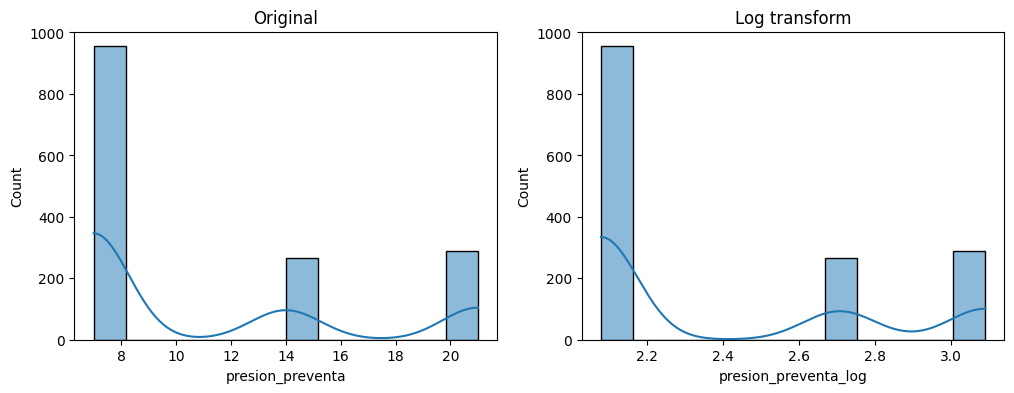

In [26]:
# Comparasión
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df['presion_preventa'], kde=True, ax=ax[0])
ax[0].set_title('Original')

sns.histplot(df['presion_preventa_log'], kde=True, ax=ax[1])
ax[1].set_title('Log transform')

plt.show()

Aunque la variable presion_preventa presentó asimetría moderada (skewness = 0.96), la transformación logarítmica no produjo mejoras significativas en la distribución debido a la naturaleza discreta de la variable. Por esta razón, se decidió conservar la escala original para mantener interpretabilidad.

# **Tendencias temporales**
¿Se identifican tendencias temporales? (En caso de que el conjunto incluya una dimensión de tiempo).

**No Aplica**

# **Correlaciones**
¿Hay correlación entre las variables dependientes e independientes?

In [27]:
# Matriz de correlación
corr_matrix = df[numeric_cols].corr()

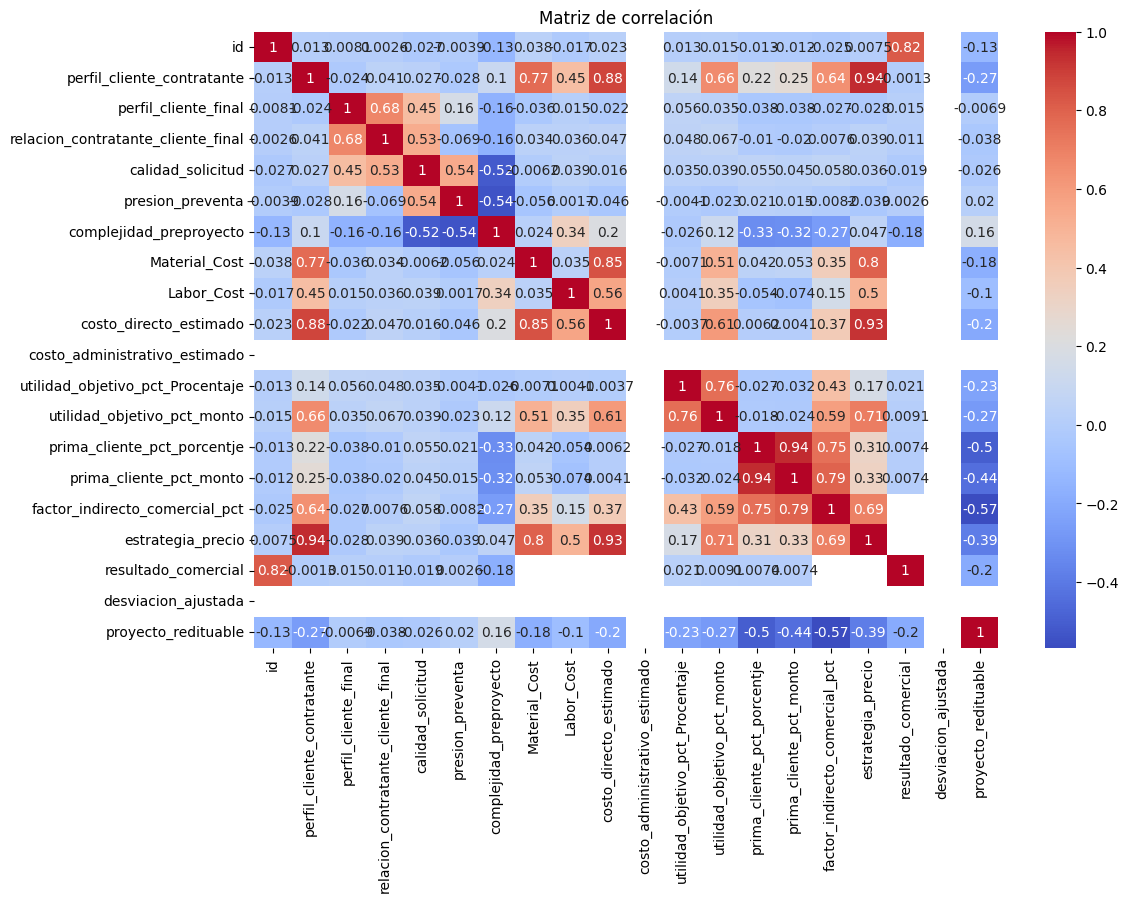

In [28]:
# Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Matriz de correlación')

plt.show()

La matriz de correlación muestra relaciones importantes entre variables asociadas a costos, márgenes y estrategia comercial.

Destacan las altas correlaciones entre estrategia_precio y costo_directo_estimado (0.93), así como entre prima_cliente_pct_porcentaje y prima_cliente_pct_monto (0.94). Estas asociaciones sugieren que algunas variables contienen información similar y podrían generar problemas de multicolinealidad en ciertos modelos.

En términos generales, predominan correlaciones bajas y moderadas, lo que indica que la mayoría de las variables aportan información complementaria. Sin embargo, las variables con correlaciones elevadas serán analizadas en etapas posteriores para determinar si es conveniente eliminar alguna de ellas y así mejorar la interpretabilidad y simplicidad del modelo.

# **Análisis bivariado**
¿Cómo se distribuyen los datos en función de diferentes categorías? (análisis bivariado)

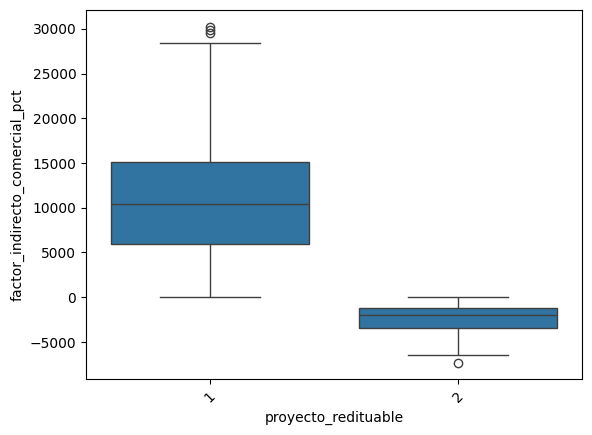

In [30]:
sns.boxplot(
    x='proyecto_redituable',
    y='factor_indirecto_comercial_pct',
    data=df
)

plt.xticks(rotation=45)

plt.show()

Podemos observar diferencias marcadas entre las categorías de proyecto_redituable respecto a factor_indirecto_comercial_pct.

Los proyectos pertenecientes a la clase 1 presentan valores considerablemente más altos y una mayor dispersión, mientras que la clase 2 se concentra principalmente en valores negativos o cercanos a cero; lo que sugiere que el factor_indirecto_comercial_pct podría ser una variable relevante para explicar la rentabilidad de los proyectos.

# **Imágenes**
¿Se deberían normalizar las imágenes para visualizarlas mejor?

**No Aplica**

# **Balance de clases**

In [31]:
# Conteo
df['resultado_comercial'].value_counts()

,count
resultado_comercial,
1,1000
2,506


In [32]:
# Proporción
df['resultado_comercial'].value_counts(normalize=True)

,proportion
resultado_comercial,
1,0.664011
2,0.335989


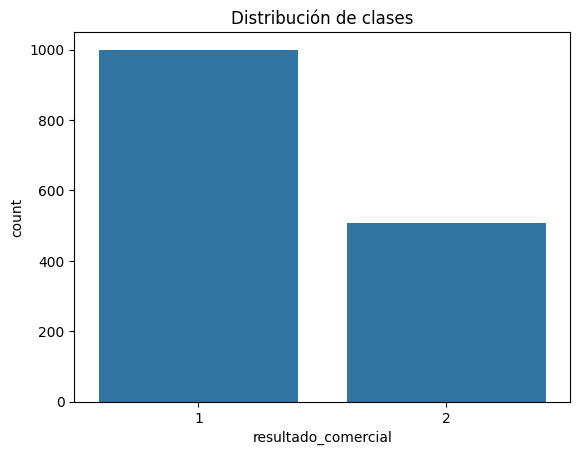

In [33]:
# Visualización
sns.countplot(
    x='resultado_comercial',
    data=df
)

plt.title('Distribución de clases')

plt.show()

Aunque existe una diferencia apreciable entre ambas categorías, consideramos que la proporción aproximada de 2 a 1 no representa un desbalance importante por lo que en esta etapa no se espera que esto represente un impacto crítico en el entrenamiento de los modelos futuros.

Contemplamos durante la etapa de modelado el uso de métricas complementarias al accuracy, como precisión, recall o F1-score, para asegurar que el desempeño del modelo sea adecuado en ambas clases.

# Referencias
*   Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., y Plöd, M. (2023). CRISP-ML(Q). The ML Lifecycle Process. MLOps. INNOQ.

*   Kumar Mukhiya, S., y Ahmed, U. (2020). Hands-On Exploratory Data Analysis with Python. Packt Publishing.